<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;max-width:960px;padding:28px 0 34px;border-top:4px solid #146c7a;border-bottom:1px solid #dfe6e9">
  <div style="color:#146c7a;font-size:12px;font-weight:700;letter-spacing:.09em;text-transform:uppercase">Cuaderno de consulta</div>
  <h1 style="color:#18242a;font-size:36px;line-height:1.16;letter-spacing:-.025em;font-weight:650;margin:15px 0 17px">Cuenta experimental de energía y emisiones al aire de Guatemala, 2018–2024</h1>
  <div style="display:flex;flex-wrap:wrap;gap:7px 20px;margin-top:26px;color:#69767d;font-size:13px"><strong style="color:#334148;font-weight:600">Juan Alejandro Osorio</strong><span>Patricia Villatoro</span><span>Noe Salguero</span><span>José Carlos Soberanis</span></div>
  <div style="margin-top:10px;color:#7a858b;font-size:12px">Créditos completos: creditos.txt</div>
</div>

Este cuaderno permite consultar los resultados producidos por el script de reproducción. Lee únicamente los dos CSV finales; no reconstruye las cuentas ni duplica el proceso de cálculo.

La lectura se organiza en cinco partes:

1. indicadores de síntesis;
2. PSUT de energía integrada;
3. emisiones al aire integradas;
4. lecturas del año seleccionado;
5. evolución durante 2018–2024.

Las cifras se presentan con un máximo de dos decimales. Los archivos conservan su precisión original.

In [1]:
#@title { display-mode: "form" }
from __future__ import annotations

import html as _html
import os
from pathlib import Path

import numpy as np
import pandas as pd

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-cuenta-energia")
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML as _HTML, clear_output as _clear_output, display as _display
    HAY_IPYTHON = True
except ImportError:
    _HTML = lambda contenido: contenido
    _clear_output = lambda wait=False: None
    _display = print
    HAY_IPYTHON = False

try:
    import ipywidgets as widgets
    HAY_WIDGETS = HAY_IPYTHON
except ImportError:
    widgets = None
    HAY_WIDGETS = False

try:
    import plotly.graph_objects as go
    HAY_PLOTLY = True
except ImportError:
    go = None
    HAY_PLOTLY = False

ARCHIVO_PSUT = "psut_energia_guatemala_2018_2024.csv"
ARCHIVO_EMISIONES = "cuenta_emisiones_aire_guatemala_2018_2024.csv"
AÑOS = tuple(range(2018, 2025))
ANIO_INICIAL = 2024

PRODUCTOS = {
    "BCANA": "Bagazo de caña", "BIOGAS": "Biogás", "COQUE": "Coque",
    "CRBN": "Carbón", "DOIL": "Diésel / gas oil", "ELEC": "Electricidad",
    "EOLICA": "Energía eólica", "FOIL": "Fuel oil", "GAS": "Gasolinas",
    "GEOE": "Geoenergía / geotermia", "GLP": "Gas licuado de petróleo (GLP)",
    "GN": "Gas natural", "HYDR": "Energía hídrica", "KER": "Keroseno",
    "LENA": "Leña", "NOEN": "Usos no energéticos", "PETR": "Petróleo crudo",
    "SOLAR": "Energía solar",
}

GRUPOS = {
    "Energy from natural inputs": "Insumos naturales de energía",
    "Energy products": "Productos energéticos",
    "Energy residuals": "Residuales energéticos",
}
FILAS_PSUT = {
    "Energy from natural inputs": ["CRBN", "EOLICA", "GEOE", "GN", "HYDR", "PETR", "SOLAR"],
    "Energy products": ["BCANA", "BIOGAS", "CRBN", "COQUE", "DOIL", "ELEC", "FOIL", "GAS", "GLP", "GN", "KER", "LENA", "NOEN", "PETR"],
    "Energy residuals": ["ELEC"],
}
UNIDADES = {
    "ENV": "Ambiente", "A": "Agricultura", "B": "Minería y canteras",
    "ENER": "Industrias de energía", "IND_BEN": "Industria",
    "TR_BEN": "Transporte", "SERV": "Comercio y servicios", "HH": "Hogares",
    "ROW": "Resto del mundo", "ACC": "Acumulación", "NO_ASIG": "Uso no asignado",
    "STAT": "Diferencia estadística",
}
ORDEN_OFERTA = ["ENV", "A", "B", "ENER", "IND_BEN", "ROW"]
ORDEN_UTILIZACION = ["ENV", "A", "B", "ENER", "IND_BEN", "TR_BEN", "SERV", "HH", "ROW", "ACC", "NO_ASIG", "STAT"]
ORDEN_UNIDADES_EMISIONES = ["A", "B", "ENER", "IND_BEN", "TR_BEN", "SERV", "HH", "NO_ASIG"]
NOMBRES_MODULO = {"COMBUSTION": "Combustión", "FUGITIVAS": "Emisiones fugitivas", "AGRICULTURA": "Agricultura"}
ORDEN_MODULOS = ["COMBUSTION", "FUGITIVAS", "AGRICULTURA"]

REQUERIDAS_PSUT = {
    "registro_mapeo", "anio", "producto", "flow_group", "lado", "bloque",
    "unidad_sectorial", "source_record_id", "metodo", "ajuste", "TJ",
    "tipo_STAT", "estado_fuente",
}
REQUERIDAS_EMISIONES = {
    "clave_emision", "anio", "unidad_sectorial_agregada", "modulo",
    "actividad_emisiones_tj", "co2_directo_kt", "co2_biogenico_memo_kt",
    "ch4_kt", "n2o_kt", "co2e_kt",
}

CSS_TABLAS = """
<style>
.cuenta-marco{border:1px solid #dfe6e9;border-radius:8px;overflow:hidden;background:#fff;margin:8px 0 6px}
.cuenta-scroll{overflow:auto;max-height:640px}
.cuenta-tabla{border-collapse:separate;border-spacing:0;width:max-content;min-width:100%;font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;font-size:12px;line-height:1.3;color:#334148;font-variant-numeric:tabular-nums lining-nums}
.cuenta-tabla th,.cuenta-tabla td{padding:9px 10px;border-right:1px solid #edf1f2;border-bottom:1px solid #e8edef}
.cuenta-tabla thead th{position:sticky;z-index:4;background:#f7f9fa;color:#45535a;text-align:center;font-weight:600;white-space:normal}
.cuenta-tabla .cab-grupo th{top:0;height:35px;background:#f3f7f8;color:#146c7a;font-size:11px;letter-spacing:.02em;text-transform:uppercase}
.cuenta-tabla .cab-columna th{top:35px;height:51px;min-width:105px}
.cuenta-tabla .esquina{left:0;z-index:8;min-width:235px;text-align:left}
.cuenta-tabla tbody .producto{position:sticky;left:0;z-index:2;min-width:235px;max-width:235px;background:#fff;text-align:left;color:#29373d;font-weight:500}
.cuenta-tabla tbody .producto small{display:block;color:#8a959a;font-size:10px;font-weight:600;letter-spacing:.02em;margin-top:2px}
.cuenta-tabla td.num{min-width:105px;text-align:right;white-space:nowrap}
.cuenta-tabla td.vacio{color:transparent}
.cuenta-tabla td.cero{color:#aeb8bc}
.cuenta-tabla td.negativo{color:#914a42}
.cuenta-tabla th.total,.cuenta-tabla td.total,.cuenta-tabla th.saldo,.cuenta-tabla td.saldo{background:#fafbfb;font-weight:650}
.cuenta-tabla .fila-grupo th{position:sticky;left:0;z-index:3;padding:12px 12px 7px;background:#fff;color:#146c7a;border-top:2px solid #cad6da;text-align:left;font-size:11px;letter-spacing:.02em;text-transform:uppercase}
.cuenta-tabla tbody tr.fila-dato:hover th,.cuenta-tabla tbody tr.fila-dato:hover td{background:#fbfdfd}
.cuenta-nota{margin:0;padding:10px 12px;border-top:1px solid #e2e8ea;color:#758188;font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;font-size:11px}
.emisiones-marco{max-width:1080px}.emisiones-marco .cuenta-scroll{max-height:520px}.emisiones-tabla .cab-columna th{top:0}.emisiones-tabla .esquina,.emisiones-tabla tbody .producto{min-width:275px;max-width:275px}.emisiones-tabla td.num,.emisiones-tabla .cab-columna th{min-width:128px}.unidad-cab{display:block;color:#859198;font-size:10px;font-weight:500;margin-top:2px}
.indicadores-marco{max-width:960px}.indicadores-marco .cuenta-scroll{max-height:none}.indicadores-tabla{width:100%;min-width:720px}.indicadores-tabla .cab-columna th{top:0;height:auto}.indicadores-tabla .esquina{min-width:420px}.indicadores-tabla tbody .producto{position:static;min-width:420px;max-width:none}.indicadores-tabla td.num{min-width:145px}.indicadores-tabla td.unidad{min-width:120px;text-align:left;color:#6f7b81;white-space:nowrap}
.indicadores-detalle{border-top:1px solid #e2e8ea}.indicadores-detalle summary{cursor:pointer;padding:11px 12px;color:#526168;font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;font-size:12px;font-weight:600}.indicadores-detalle .cuenta-scroll{border-top:1px solid #edf1f2}.oferta-periodo-marco{max-width:1080px}.oferta-periodo-tabla{width:100%;min-width:960px}.oferta-periodo-tabla .cab-columna th{top:0;height:auto;min-width:120px}.oferta-periodo-tabla .esquina{min-width:74px}.oferta-periodo-tabla tbody .producto{position:static;min-width:74px;max-width:74px;text-align:center}.oferta-periodo-tabla td.num{min-width:120px}
</style>
"""

def _localizar_archivos():
    bases = [
        Path.cwd(),
        Path.cwd() / "outputs" / "datasets_finales",
        Path.cwd() / "datasets_finales",
        Path.cwd().parent / "datasets_finales",
        Path("outputs") / "datasets_finales",
        Path("..") / "datasets_finales",
    ]
    rutas = {}
    for nombre in (ARCHIVO_PSUT, ARCHIVO_EMISIONES):
        for base in bases:
            candidata = base / nombre
            if candidata.is_file():
                rutas[nombre] = candidata.resolve()
                break
    if len(rutas) == 2:
        return rutas[ARCHIVO_PSUT], rutas[ARCHIVO_EMISIONES]
    try:
        from google.colab import files
    except ImportError as exc:
        faltan = sorted({ARCHIVO_PSUT, ARCHIVO_EMISIONES}.difference(rutas))
        raise FileNotFoundError(f"No se encontraron los archivos: {faltan}") from exc
    faltan = [nombre for nombre in (ARCHIVO_PSUT, ARCHIVO_EMISIONES) if nombre not in rutas]
    for nombre in faltan:
        print(f"Seleccione el archivo {nombre}.")
        files.upload_file(nombre)
        if not Path(nombre).is_file():
            raise FileNotFoundError(f"No se cargó el archivo: {nombre}")
    return Path(ARCHIVO_PSUT).resolve(), Path(ARCHIVO_EMISIONES).resolve()

RUTA_PSUT, RUTA_EMISIONES = _localizar_archivos()
psut = pd.read_csv(RUTA_PSUT)
emisiones = pd.read_csv(RUTA_EMISIONES)

faltantes_psut = REQUERIDAS_PSUT.difference(psut.columns)
faltantes_emisiones = REQUERIDAS_EMISIONES.difference(emisiones.columns)
if faltantes_psut:
    raise ValueError(f"Faltan columnas PSUT: {sorted(faltantes_psut)}")
if faltantes_emisiones:
    raise ValueError(f"Faltan columnas de emisiones: {sorted(faltantes_emisiones)}")

psut["anio"] = pd.to_numeric(psut["anio"], errors="raise").astype(int)
psut["TJ"] = pd.to_numeric(psut["TJ"], errors="raise")
emisiones["anio"] = pd.to_numeric(emisiones["anio"], errors="raise").astype(int)
for columna in ["actividad_emisiones_tj", "co2_directo_kt", "co2_biogenico_memo_kt", "ch4_kt", "n2o_kt", "co2e_kt"]:
    emisiones[columna] = pd.to_numeric(emisiones[columna], errors="coerce")

if set(psut["anio"]) != set(AÑOS) or set(emisiones["anio"]) != set(AÑOS):
    raise ValueError("Los dos resultados deben cubrir exactamente 2018–2024.")
if psut["registro_mapeo"].duplicated().any() or emisiones["clave_emision"].duplicated().any():
    raise ValueError("Se encontraron claves duplicadas en los resultados finales.")
if not np.isfinite(psut["TJ"]).all():
    raise ValueError("La PSUT contiene valores TJ no finitos.")

def _indice_psut():
    filas = []
    for grupo, productos in FILAS_PSUT.items():
        for codigo in productos:
            filas.append((GRUPOS[grupo], codigo, PRODUCTOS[codigo]))
    return pd.MultiIndex.from_tuples(filas, names=["Grupo", "Código", "Producto"])

def _unidades_activas(lado, orden):
    observadas = set(psut.loc[psut["lado"].eq(lado), "unidad_sectorial"])
    return [unidad for unidad in orden if unidad in observadas]

def matriz_psut_integrada(anio):
    anio = int(anio)
    oferta = _unidades_activas("Supply", ORDEN_OFERTA)
    utilizacion = _unidades_activas("Use", ORDEN_UTILIZACION)
    indice = _indice_psut()
    matriz = pd.DataFrame(index=indice)
    anual = psut.loc[psut["anio"].eq(anio)]
    agregados = anual.groupby(["flow_group", "producto", "lado", "unidad_sectorial"], observed=True)["TJ"].sum(min_count=1)
    inverso = {nombre: codigo for codigo, nombre in GRUPOS.items()}
    for lado, titulo, unidades in (("Supply", "Oferta", oferta), ("Use", "Utilización", utilizacion)):
        for unidad in unidades:
            valores = pd.Series(pd.NA, index=indice, dtype="Float64")
            for clave_fila in indice:
                grupo_nombre, codigo, _ = clave_fila
                clave = (inverso[grupo_nombre], codigo, lado, unidad)
                if clave in agregados.index:
                    valores.loc[clave_fila] = float(agregados.loc[clave])
            matriz[(titulo, UNIDADES[unidad])] = valores
        columnas = [(titulo, UNIDADES[u]) for u in unidades]
        matriz[(titulo, f"Total {titulo.lower()}")] = matriz[columnas].sum(axis=1, min_count=1).astype("Float64")
    total_oferta = matriz[("Oferta", "Total oferta")]
    total_uso = matriz[("Utilización", "Total utilización")]
    hay_flujo = total_oferta.notna() | total_uso.notna()
    matriz[("Saldo", "Oferta − utilización")] = (total_oferta.fillna(0) - total_uso.fillna(0)).where(hay_flujo).astype("Float64")
    matriz.columns = pd.MultiIndex.from_tuples(matriz.columns, names=["Componente", "Unidad institucional"])
    return matriz

def _fmt(valor):
    if pd.isna(valor):
        return "", "vacio"
    numero = float(valor)
    if abs(numero) < 0.005:
        numero = 0.0
    texto = f"{numero:,.2f}".rstrip("0").rstrip(".")
    clase = "cero" if numero == 0 else ("negativo" if numero < 0 else "")
    return texto, clase

def _td_numero(valor, extra=""):
    texto, estado = _fmt(valor)
    clase = "num"
    if estado:
        clase += f" {estado}"
    if extra:
        clase += f" {extra}"
    return f'<td class="{clase}">{_html.escape(texto)}</td>'

def tabla_psut_html(anio):
    matriz = matriz_psut_integrada(anio)
    grupos_columnas = []
    for componente in matriz.columns.get_level_values(0).unique():
        grupos_columnas.append((componente, int((matriz.columns.get_level_values(0) == componente).sum())))
    cabecera_grupos = ''.join(f'<th colspan="{n}">{_html.escape(c)}</th>' for c, n in grupos_columnas)
    cabecera_columnas = ''.join(
        f'<th class="{"total" if nombre.startswith("Total") else ("saldo" if componente == "Saldo" else "")}">{_html.escape(nombre)}</th>'
        for componente, nombre in matriz.columns
    )
    filas = []
    grupo_anterior = None
    for (grupo, codigo, producto), fila in matriz.iterrows():
        if grupo != grupo_anterior:
            filas.append(f'<tr class="fila-grupo"><th colspan="{len(matriz.columns)+1}">{_html.escape(grupo)}</th></tr>')
            grupo_anterior = grupo
        celdas = []
        for (componente, nombre), valor in fila.items():
            extra = "total" if nombre.startswith("Total") else ("saldo" if componente == "Saldo" else "")
            celdas.append(_td_numero(valor, extra))
        filas.append(
            '<tr class="fila-dato">'
            f'<th class="producto">{_html.escape(producto)}<small>{_html.escape(codigo)}</small></th>'
            + ''.join(celdas) + '</tr>'
        )
    return f"""{CSS_TABLAS}<div class="cuenta-marco"><div class="cuenta-scroll"><table class="cuenta-tabla">
    <thead><tr class="cab-grupo"><th rowspan="2" class="esquina">Flujo energético</th>{cabecera_grupos}</tr>
    <tr class="cab-columna">{cabecera_columnas}</tr></thead><tbody>{''.join(filas)}</tbody></table></div>
    <p class="cuenta-nota">Año {int(anio)} · Unidad: terajulios (TJ). Las celdas sin registro permanecen vacías.</p></div>"""

def tabla_emisiones_integrada(anio):
    columnas = ["actividad_emisiones_tj", "co2_directo_kt", "co2_biogenico_memo_kt", "ch4_kt", "n2o_kt", "co2e_kt"]
    anual = emisiones.loc[emisiones["anio"].eq(int(anio))]
    tabla = anual.groupby(["modulo", "unidad_sectorial_agregada"], observed=True)[columnas].sum(min_count=1)
    filas = []
    for modulo in ORDEN_MODULOS:
        if modulo not in tabla.index.get_level_values(0):
            continue
        filas.append(f'<tr class="fila-grupo"><th colspan="7">{_html.escape(NOMBRES_MODULO[modulo])}</th></tr>')
        sub = tabla.xs(modulo, level=0)
        unidades = [u for u in ORDEN_UNIDADES_EMISIONES if u in sub.index]
        for unidad in unidades:
            fila = sub.loc[unidad]
            filas.append(
                '<tr class="fila-dato">'
                f'<th class="producto">{_html.escape(UNIDADES.get(unidad, unidad))}</th>'
                + ''.join(_td_numero(fila[c]) for c in columnas) + '</tr>'
            )
    return f"""{CSS_TABLAS}<div class="cuenta-marco emisiones-marco"><div class="cuenta-scroll"><table class="cuenta-tabla emisiones-tabla">
    <thead><tr class="cab-columna"><th class="esquina">Unidad</th>
    <th>Actividad<span class="unidad-cab">TJ</span></th><th>CO₂ directo<span class="unidad-cab">kt</span></th>
    <th>CO₂ biogénico<span class="unidad-cab">kt · informativo</span></th><th>CH₄<span class="unidad-cab">kt</span></th>
    <th>N₂O<span class="unidad-cab">kt</span></th><th>Total cuantificado<span class="unidad-cab">kt CO₂e</span></th></tr></thead>
    <tbody>{''.join(filas)}</tbody></table></div><p class="cuenta-nota">Año {int(anio)}. El CO₂ biogénico se informa por separado.</p></div>"""

def _produccion_primaria_nacional():
    insumos = psut.loc[
        psut["flow_group"].eq("Energy from natural inputs")
        & psut["lado"].eq("Supply")
        & psut["bloque"].eq("A")
        & psut["unidad_sectorial"].eq("ENV")
    ]
    fronteras = psut.loc[
        psut["flow_group"].eq("Energy products")
        & psut["lado"].eq("Supply")
        & psut["bloque"].eq("C")
        & psut["metodo"].isin({"FRONTERA_LENA_A", "FRONTERA_BAGAZO_IND", "FRONTERA_BIOGAS_ENER"})
    ]
    return pd.concat([insumos, fronteras], ignore_index=True)

def balance_oferta_primaria_aparente():
    produccion = _produccion_primaria_nacional().groupby("anio", observed=True)["TJ"].sum()
    importaciones = psut.loc[
        psut["flow_group"].eq("Energy products")
        & psut["lado"].eq("Supply")
        & psut["bloque"].eq("D")
        & psut["unidad_sectorial"].eq("ROW")
    ].groupby("anio", observed=True)["TJ"].sum()
    exportaciones = psut.loc[
        psut["flow_group"].eq("Energy products")
        & psut["lado"].eq("Use")
        & psut["bloque"].eq("H")
        & psut["unidad_sectorial"].eq("ROW")
    ].groupby("anio", observed=True)["TJ"].sum()
    existencias = psut.loc[
        psut["flow_group"].eq("Energy products")
        & psut["bloque"].eq("G")
        & psut["unidad_sectorial"].eq("ACC")
    ].assign(
        cambio_firmado=lambda d: d["TJ"] * d["lado"].map({"Supply": -1.0, "Use": 1.0})
    ).groupby("anio", observed=True)["cambio_firmado"].sum()
    tabla = pd.DataFrame({
        "Producción primaria nacional": produccion,
        "Importaciones": importaciones,
        "Exportaciones": exportaciones,
        "Cambio de existencias": existencias,
    }).reindex(AÑOS).fillna(0.0)
    tabla["Oferta primaria aparente"] = (
        tabla["Producción primaria nacional"]
        + tabla["Importaciones"]
        - tabla["Exportaciones"]
        - tabla["Cambio de existencias"]
    )
    tabla["Dependencia neta aparente (%)"] = 100.0 * (
        tabla["Importaciones"] - tabla["Exportaciones"]
    ) / tabla["Oferta primaria aparente"]
    return tabla

def _uso_final_sectorial():
    return psut.loc[
        psut["flow_group"].eq("Energy products")
        & psut["lado"].eq("Use")
        & psut["metodo"].isin({"USO_TR_BEN", "USO_IND_BEN", "USO_SERV", "USO_HH"})
        & psut["unidad_sectorial"].isin({"IND_BEN", "TR_BEN", "SERV", "HH"})
    ].copy()

def _uso_no_asignado():
    return psut.loc[
        psut["flow_group"].eq("Energy products")
        & psut["lado"].eq("Use")
        & psut["metodo"].eq("USO_ENERGETICO_INTERNO_APARENTE")
        & psut["unidad_sectorial"].eq("NO_ASIG")
    ].copy()

def indicadores_anuales(anio):
    anio = int(anio)
    anual_psut = psut.loc[psut["anio"].eq(anio)]
    anual_em = emisiones.loc[emisiones["anio"].eq(anio)]
    uso = _uso_final_sectorial().loc[lambda d: d["anio"].eq(anio)]
    uso_total = float(uso["TJ"].sum())
    hogares = float(uso.loc[uso["unidad_sectorial"].eq("HH"), "TJ"].sum())
    uso_propio = float(anual_psut.loc[
        anual_psut["flow_group"].eq("Energy products")
        & anual_psut["lado"].eq("Use")
        & anual_psut["metodo"].eq("USO_ENER")
        & anual_psut["unidad_sectorial"].eq("ENER"), "TJ"
    ].sum())
    no_asignado = float(_uso_no_asignado().loc[lambda d: d["anio"].eq(anio), "TJ"].sum())
    uso_no_energetico = float(anual_psut.loc[
        anual_psut["flow_group"].eq("Energy products")
        & anual_psut["lado"].eq("Use")
        & anual_psut["metodo"].eq("USO_NO_ENERGETICO_APARENTE"), "TJ"
    ].sum())
    residuales = float(anual_psut.loc[
        anual_psut["flow_group"].eq("Energy residuals")
        & anual_psut["lado"].eq("Supply")
        & anual_psut["bloque"].eq("I"), "TJ"
    ].sum())
    ajustes_stat = anual_psut.loc[anual_psut["unidad_sectorial"].eq("STAT"), "TJ"].abs()
    oferta = balance_oferta_primaria_aparente().loc[anio]
    filas = [
        ("Oferta", "Producción primaria nacional", oferta["Producción primaria nacional"], "TJ"),
        ("Oferta", "Oferta primaria aparente", oferta["Oferta primaria aparente"], "TJ"),
        ("Oferta", "Dependencia neta aparente", oferta["Dependencia neta aparente (%)"], "%"),
        ("Utilización", "Uso final sectorial", uso_total, "TJ"),
        ("Utilización", "Uso final ampliado (sectores finales + no asignado)", uso_total + no_asignado, "TJ"),
        ("Utilización", "Participación de hogares", 100.0 * hogares / uso_total if uso_total else 0.0, "%"),
        ("Utilización", "Uso propio de industrias energéticas", uso_propio, "TJ"),
        ("Utilización", "Uso energético no asignado", no_asignado, "TJ"),
        ("Utilización", "Uso no energético", uso_no_energetico, "TJ"),
        ("Utilización", "Residuales energéticos", residuales, "TJ"),
        ("Emisiones", "Emisiones cuantificadas totales", anual_em["co2e_kt"].sum(min_count=1), "kt CO₂e"),
        ("Emisiones", "CO₂ biogénico informativo", anual_em["co2_biogenico_memo_kt"].sum(min_count=1), "kt"),
        ("Cierre", "Suma de ajustes STAT absolutos", ajustes_stat.sum() if len(ajustes_stat) else 0.0, "TJ"),
        ("Cierre", "Mayor ajuste STAT absoluto", ajustes_stat.max() if len(ajustes_stat) else 0.0, "TJ"),
    ]
    return pd.DataFrame(filas, columns=["Grupo", "Indicador", "Valor", "Unidad"])

def tabla_indicadores_html(anio):
    tabla = indicadores_anuales(anio)
    principales = tabla.iloc[[0, 1, 2, 3, 4, 5, 9, 10]].copy()
    complementarios = tabla.drop(index=principales.index).copy()
    def construir_filas(subtabla):
        filas = []
        grupo_anterior = None
        for fila in subtabla.itertuples(index=False):
            if fila.Grupo != grupo_anterior:
                filas.append(f'<tr class="fila-grupo"><th colspan="3">{_html.escape(fila.Grupo)}</th></tr>')
                grupo_anterior = fila.Grupo
            filas.append(
                '<tr class="fila-dato">'
                f'<th class="producto">{_html.escape(fila.Indicador)}</th>'
                + _td_numero(fila.Valor)
                + f'<td class="unidad">{_html.escape(fila.Unidad)}</td></tr>'
            )
        return ''.join(filas)
    filas_principales = construir_filas(principales)
    filas_complementarias = construir_filas(complementarios)
    cabecera = '<thead><tr class="cab-columna"><th class="esquina">Indicador</th><th>Valor</th><th>Unidad</th></tr></thead>'
    return f"""{CSS_TABLAS}<div class="cuenta-marco indicadores-marco"><div class="cuenta-scroll"><table class="cuenta-tabla indicadores-tabla">
    {cabecera}<tbody>{filas_principales}</tbody></table></div>
    <details class="indicadores-detalle"><summary>Indicadores complementarios</summary><div class="cuenta-scroll"><table class="cuenta-tabla indicadores-tabla">{cabecera}<tbody>{filas_complementarias}</tbody></table></div></details>
    <p class="cuenta-nota">Año {int(anio)}. Las cifras se redondean solo para su presentación.</p></div>"""

def tabla_oferta_periodo_html():
    tabla = balance_oferta_primaria_aparente()
    columnas = [
        "Producción primaria nacional", "Importaciones", "Exportaciones",
        "Cambio de existencias", "Oferta primaria aparente", "Dependencia neta aparente (%)",
    ]
    etiquetas = [
        "Producción primaria", "Importaciones", "Exportaciones",
        "Cambio de existencias", "Oferta primaria aparente", "Dependencia neta aparente",
    ]
    unidades = ["TJ", "TJ", "TJ", "TJ", "TJ", "%"]
    cabecera = ''.join(
        f'<th>{_html.escape(etiqueta)}<span class="unidad-cab">{_html.escape(unidad)}</span></th>'
        for etiqueta, unidad in zip(etiquetas, unidades)
    )
    filas = []
    for anio, fila in tabla[columnas].iterrows():
        filas.append(
            '<tr class="fila-dato">'
            f'<th class="producto">{int(anio)}</th>'
            + ''.join(_td_numero(fila[columna]) for columna in columnas)
            + '</tr>'
        )
    return f"""{CSS_TABLAS}<div class="cuenta-marco oferta-periodo-marco"><div class="cuenta-scroll"><table class="cuenta-tabla oferta-periodo-tabla">
    <thead><tr class="cab-columna"><th class="esquina">Año</th>{cabecera}</tr></thead><tbody>{''.join(filas)}</tbody>
    </table></div><p class="cuenta-nota">La oferta primaria aparente se obtiene como producción primaria nacional + importaciones − exportaciones − cambio de existencias.</p></div>"""

def serie_uso_sector():
    metodos = {"USO_TR_BEN", "USO_IND_BEN", "USO_SERV", "USO_HH"}
    base = psut.loc[psut["flow_group"].eq("Energy products") & psut["lado"].eq("Use") & psut["metodo"].isin(metodos)]
    tabla = base.pivot_table(index="anio", columns="unidad_sectorial", values="TJ", aggfunc="sum", fill_value=0.0, observed=True).reindex(AÑOS, fill_value=0.0)
    no_asig = psut.loc[
        psut["flow_group"].eq("Energy products")
        & psut["lado"].eq("Use")
        & psut["unidad_sectorial"].eq("NO_ASIG")
        & psut["metodo"].eq("USO_ENERGETICO_INTERNO_APARENTE")
    ].groupby("anio", observed=True)["TJ"].sum()
    tabla["NO_ASIG"] = no_asig.reindex(AÑOS, fill_value=0.0)
    orden = ["IND_BEN", "TR_BEN", "SERV", "HH", "NO_ASIG"]
    return tabla.reindex(columns=orden, fill_value=0.0).rename(columns=UNIDADES)

def serie_uso_final():
    return serie_uso_sector()

def serie_uso_producto():
    base = pd.concat([_uso_final_sectorial(), _uso_no_asignado()], ignore_index=True)
    completa = base.pivot_table(index="anio", columns="producto", values="TJ", aggfunc="sum", fill_value=0.0, observed=True).reindex(AÑOS, fill_value=0.0)
    completa = completa.rename(columns=PRODUCTOS)
    principales = completa.sum().nlargest(6).index
    reducida = completa.loc[:, principales].copy()
    otros = completa.drop(columns=principales).sum(axis=1)
    if otros.abs().sum() > 0:
        reducida["Otros productos"] = otros
    return reducida

def uso_anual_producto(anio):
    metodos = {"USO_TR_BEN", "USO_IND_BEN", "USO_SERV", "USO_HH", "USO_ENERGETICO_INTERNO_APARENTE"}
    base = psut.loc[
        psut["anio"].eq(int(anio))
        & psut["flow_group"].eq("Energy products")
        & psut["lado"].eq("Use")
        & psut["metodo"].isin(metodos)
    ]
    serie = base.groupby("producto", observed=True)["TJ"].sum().sort_values()
    serie.index = [PRODUCTOS.get(codigo, codigo) for codigo in serie.index]
    return serie

def serie_emisiones_modulo():
    tabla = emisiones.pivot_table(index="anio", columns="modulo", values="co2e_kt", aggfunc="sum", fill_value=0.0, observed=True).reindex(AÑOS, fill_value=0.0)
    return tabla.reindex(columns=ORDEN_MODULOS, fill_value=0.0).rename(columns=NOMBRES_MODULO)

def serie_aportes_gases():
    por_anio = emisiones.groupby("anio", observed=True).agg(
        co2=("co2_directo_kt", "sum"),
        ch4=("ch4_kt", "sum"),
        n2o=("n2o_kt", "sum"),
    ).reindex(AÑOS, fill_value=0.0)
    return pd.DataFrame({
        "CO₂ directo": por_anio["co2"],
        "CH₄ en CO₂e": por_anio["ch4"] * 28.0,
        "N₂O en CO₂e": por_anio["n2o"] * 265.0,
    })

def emisiones_anuales_modulo(anio):
    serie = emisiones.loc[emisiones["anio"].eq(int(anio))].groupby("modulo", observed=True)["co2e_kt"].sum(min_count=1)
    serie = serie.reindex(ORDEN_MODULOS).dropna()
    serie.index = [NOMBRES_MODULO.get(codigo, codigo) for codigo in serie.index]
    return serie

def emisiones_anuales_gas(anio):
    anual = emisiones.loc[emisiones["anio"].eq(int(anio))]
    return pd.Series({
        "CO₂ directo": anual["co2_directo_kt"].sum(min_count=1),
        "CH₄ en CO₂e": anual["ch4_kt"].sum(min_count=1) * 28.0,
        "N₂O en CO₂e": anual["n2o_kt"].sum(min_count=1) * 265.0,
    })

PALETA = ["#146c7a", "#55a3a7", "#8fae96", "#d29a50", "#806e9d"]
SUBCABECERA_GRAFICO = '<div style="font-family:-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica,Arial,sans-serif;margin:24px 0 8px;padding-bottom:7px;border-bottom:1px solid #e1e7e9;color:#26353b;font-size:17px;font-weight:600">{}</div>'

def _estilo_eje(ax, ylabel):
    ax.set_ylabel(ylabel, color="#5f6b72")
    ax.grid(axis="y", color="#e8edef", linewidth=0.8)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#dce3e6")
    ax.tick_params(colors="#5f6b72")
    ax.set_xticks(list(AÑOS))

def figura_uso_anual_unidad_matplotlib(anio):
    serie = serie_uso_final().loc[int(anio)].sort_values()
    serie = serie.mask(serie.abs() < 0.005, 0.0)
    fig, ax = plt.subplots(figsize=(10.8, 4.8), dpi=110)
    barras = ax.barh(serie.index, serie.values, color=PALETA[:len(serie)])
    ax.bar_label(barras, fmt="{:,.2f}", padding=4, fontsize=8, color="#526168")
    ax.grid(axis="x", color="#e8edef", linewidth=0.8)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#dce3e6")
    ax.tick_params(colors="#5f6b72")
    ax.set_xlabel("TJ", color="#5f6b72")
    fig.subplots_adjust(left=0.25, right=0.92, top=0.96, bottom=0.15)
    return fig

def figura_uso_anual_producto_matplotlib(anio):
    serie = uso_anual_producto(anio)
    alto = max(5.2, 0.39 * len(serie) + 1.4)
    fig, ax = plt.subplots(figsize=(10.8, alto), dpi=110)
    barras = ax.barh(serie.index, serie.values, color="#146c7a")
    ax.bar_label(barras, fmt="{:,.2f}", padding=4, fontsize=8, color="#526168")
    ax.grid(axis="x", color="#e8edef", linewidth=0.8)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#dce3e6")
    ax.tick_params(colors="#5f6b72", labelsize=9)
    ax.set_xlabel("TJ", color="#5f6b72")
    fig.subplots_adjust(left=0.30, right=0.92, top=0.98, bottom=0.10)
    return fig

def figura_emisiones_anual_modulo_matplotlib(anio):
    serie = emisiones_anuales_modulo(anio).sort_values()
    fig, ax = plt.subplots(figsize=(10.8, 4.5), dpi=110)
    barras = ax.barh(serie.index, serie.values, color=["#806e9d", "#b65d54", "#d29a50"][:len(serie)])
    ax.bar_label(barras, fmt="{:,.2f}", padding=4, fontsize=8, color="#526168")
    ax.grid(axis="x", color="#e8edef", linewidth=0.8)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#dce3e6")
    ax.tick_params(colors="#5f6b72")
    ax.set_xlabel("kt CO₂e", color="#5f6b72")
    if int(anio) >= 2023:
        ax.text(0.99, 0.98, "Incluye aproximaciones", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="#6f7b81")
    fig.subplots_adjust(left=0.22, right=0.92, top=0.96, bottom=0.16)
    return fig

def figura_emisiones_anual_gas_matplotlib(anio):
    serie = emisiones_anuales_gas(anio).sort_values()
    fig, ax = plt.subplots(figsize=(10.8, 4.5), dpi=110)
    barras = ax.barh(serie.index, serie.values, color=["#d29a50", "#8fae96", "#146c7a"][:len(serie)])
    ax.bar_label(barras, fmt="{:,.2f}", padding=4, fontsize=8, color="#526168")
    ax.grid(axis="x", color="#e8edef", linewidth=0.8)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#dce3e6")
    ax.tick_params(colors="#5f6b72")
    ax.set_xlabel("kt CO₂e", color="#5f6b72")
    if int(anio) >= 2023:
        ax.text(0.99, 0.98, "Incluye aproximaciones", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="#6f7b81")
    fig.subplots_adjust(left=0.20, right=0.92, top=0.96, bottom=0.16)
    return fig

def _estilo_periodo(ax, ylabel, *, leyenda_columnas=3, linea_cero=False):
    ax.set_ylabel(ylabel, color="#5f6b72")
    ax.set_xlabel("")
    ax.grid(axis="y", color="#e8edef", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#dce3e6")
    ax.tick_params(colors="#5f6b72", rotation=0)
    if linea_cero:
        ax.axhline(0, color="#909ba0", linewidth=1.0, zorder=1)
    ax.legend(frameon=False, ncol=leyenda_columnas, loc="upper left", bbox_to_anchor=(0, -0.15))

def figura_uso_periodo_usuario_matplotlib():
    tabla = serie_uso_sector()
    colores = ["#146c7a", "#4d939a", "#8fae96", "#d29a50", "#9aa4a8"]
    fig, ax = plt.subplots(figsize=(10.8, 5.2), dpi=110)
    tabla.plot.bar(stacked=True, ax=ax, color=colores[:len(tabla.columns)], width=0.72)
    _estilo_periodo(ax, "TJ", leyenda_columnas=3)
    fig.subplots_adjust(bottom=0.28, left=0.09, right=0.98, top=0.97)
    return fig

def figura_uso_periodo_producto_matplotlib():
    tabla = serie_uso_producto()
    colores = ["#146c7a", "#418b92", "#6e9fa0", "#8fae96", "#c1a46c", "#d29a50", "#9aa4a8"]
    fig, ax = plt.subplots(figsize=(10.8, 5.4), dpi=110)
    tabla.plot.bar(stacked=True, ax=ax, color=colores[:len(tabla.columns)], width=0.72)
    _estilo_periodo(ax, "TJ", leyenda_columnas=3)
    fig.subplots_adjust(bottom=0.31, left=0.09, right=0.98, top=0.97)
    return fig

def figura_oferta_componentes_matplotlib():
    tabla = balance_oferta_primaria_aparente()[[
        "Producción primaria nacional", "Importaciones", "Oferta primaria aparente"
    ]]
    fig, ax = plt.subplots(figsize=(10.8, 4.9), dpi=110)
    for color, columna in zip(["#146c7a", "#d29a50", "#806e9d"], tabla.columns):
        ax.plot(tabla.index, tabla[columna], color=color, linewidth=2.3, marker="o", markersize=4.8, label=columna)
    _estilo_eje(ax, "TJ")
    ax.legend(frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.17))
    fig.subplots_adjust(bottom=0.27, left=0.09, right=0.98, top=0.96)
    return fig

def figura_oferta_ajustes_matplotlib():
    tabla = balance_oferta_primaria_aparente()[["Exportaciones", "Cambio de existencias"]]
    fig, ax = plt.subplots(figsize=(10.8, 4.9), dpi=110)
    for color, columna in zip(["#55a3a7", "#d29a50"], tabla.columns):
        ax.plot(tabla.index, tabla[columna], color=color, linewidth=2.3, marker="o", markersize=4.8, label=columna)
    _estilo_eje(ax, "TJ")
    ax.axhline(0, color="#909ba0", linewidth=1.0)
    ax.legend(frameon=False, ncol=2, loc="upper left", bbox_to_anchor=(0, -0.17))
    fig.subplots_adjust(bottom=0.27, left=0.09, right=0.98, top=0.96)
    return fig

def figura_emisiones_periodo_modulo_matplotlib():
    tabla = serie_emisiones_modulo()
    colores = ["#d29a50", "#b65d54", "#806e9d"]
    fig, ax = plt.subplots(figsize=(10.8, 5.2), dpi=110)
    tabla.plot.bar(stacked=True, ax=ax, color=colores[:len(tabla.columns)], width=0.72)
    ax.axvspan(4.5, 6.5, color="#e7ecee", alpha=0.55, zorder=0)
    ax.text(5.5, 0.97, "Incluye aproximaciones", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=8.5, color="#6f7b81")
    _estilo_periodo(ax, "kt CO₂e", leyenda_columnas=3)
    fig.subplots_adjust(bottom=0.27, left=0.09, right=0.98, top=0.97)
    return fig

def figura_emisiones_periodo_gas_matplotlib():
    tabla = serie_aportes_gases()
    colores = ["#146c7a", "#8fae96", "#d29a50"]
    fig, ax = plt.subplots(figsize=(10.8, 5.2), dpi=110)
    tabla.plot.bar(stacked=True, ax=ax, color=colores, width=0.72)
    ax.axvspan(4.5, 6.5, color="#e7ecee", alpha=0.55, zorder=0)
    ax.text(5.5, 0.97, "Incluye aproximaciones", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=8.5, color="#6f7b81")
    _estilo_periodo(ax, "kt CO₂e", leyenda_columnas=3)
    fig.subplots_adjust(bottom=0.27, left=0.09, right=0.98, top=0.97)
    return fig

def serie_indice_energia_emisiones():
    uso_total = serie_uso_sector().sum(axis=1)
    combustion = serie_emisiones_modulo()["Combustión"]
    return pd.DataFrame({
        "Uso final ampliado": 100.0 * uso_total / uso_total.loc[2018],
        "Emisiones de combustión": 100.0 * combustion / combustion.loc[2018],
    })

def figura_indice_energia_emisiones_matplotlib():
    tabla = serie_indice_energia_emisiones()
    fig, ax = plt.subplots(figsize=(10.8, 4.9), dpi=110)
    ax.plot(tabla.index, tabla["Uso final ampliado"], color="#146c7a", linewidth=2.4, marker="o", markersize=4.8, label="Uso final ampliado")
    ax.plot(tabla.index[:5], tabla["Emisiones de combustión"].iloc[:5], color="#b65d54", linewidth=2.4, marker="o", markersize=4.8, label="Emisiones de combustión")
    ax.plot(tabla.index[4:], tabla["Emisiones de combustión"].iloc[4:], color="#b65d54", linewidth=2.4, linestyle="--", marker="o", markersize=4.8)
    ax.axvspan(2022.5, 2024.5, color="#e7ecee", alpha=0.55, zorder=0)
    ax.axhline(100, color="#909ba0", linewidth=1.0)
    ax.text(2023.5, 0.04, "Emisiones: aproximaciones", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=8.5, color="#6f7b81")
    _estilo_eje(ax, "Índice (2018 = 100)")
    ax.legend(frameon=False, ncol=2, loc="upper left", bbox_to_anchor=(0, -0.17))
    fig.subplots_adjust(bottom=0.27, left=0.09, right=0.98, top=0.96)
    return fig

def _grafico_plotly(tabla, eje_y):
    fig = go.Figure()
    for color, columna in zip(PALETA, tabla.columns):
        fig.add_trace(go.Scatter(x=tabla.index, y=tabla[columna], name=columna, mode="lines+markers", line={"color": color, "width": 2.5}, marker={"size": 7}))
    fig.update_layout(template="plotly_white", height=470, margin={"l": 65, "r": 25, "t": 20, "b": 105}, font={"family": "Arial, sans-serif", "size": 12, "color": "#334148"}, hovermode="x unified", legend={"orientation": "h", "x": 0, "y": -0.2})
    fig.update_xaxes(dtick=1, gridcolor="#f0f3f4", title=None)
    fig.update_yaxes(title=eje_y, gridcolor="#e8edef", zeroline=False)
    fig.show(config={"displaylogo": False, "responsive": True})

def _barras_plotly(serie, eje_x, nota=None):
    fig = go.Figure(go.Bar(x=serie.values, y=serie.index, orientation="h", marker_color="#146c7a", text=[f"{v:,.2f}" for v in serie.values], textposition="outside", cliponaxis=False))
    fig.update_layout(template="plotly_white", height=max(420, 34 * len(serie) + 120), margin={"l": 210, "r": 95, "t": 15, "b": 65}, font={"family": "Arial, sans-serif", "size": 12, "color": "#334148"}, showlegend=False)
    fig.update_xaxes(title=eje_x, gridcolor="#e8edef", zeroline=False)
    fig.update_yaxes(title=None)
    if nota:
        fig.add_annotation(text=nota, xref="paper", yref="paper", x=0.99, y=0.98, showarrow=False, xanchor="right", yanchor="top", font={"size": 11, "color": "#6f7b81"})
    fig.show(config={"displaylogo": False, "responsive": True})

def _apilado_plotly(tabla, eje_y, colores, *, aproximado=False):
    fig = go.Figure()
    for color, columna in zip(colores, tabla.columns):
        fig.add_trace(go.Bar(x=tabla.index, y=tabla[columna], name=columna, marker_color=color))
    fig.update_layout(barmode="stack", template="plotly_white", height=500, margin={"l": 65, "r": 25, "t": 25, "b": 115}, font={"family": "Arial, sans-serif", "size": 12, "color": "#334148"}, legend={"orientation": "h", "x": 0, "y": -0.2}, hovermode="x unified")
    if aproximado:
        fig.add_vrect(x0=2022.5, x1=2024.5, fillcolor="#e7ecee", opacity=0.45, line_width=0, annotation_text="Incluye aproximaciones", annotation_position="top")
    fig.update_xaxes(dtick=1, gridcolor="#f0f3f4", title=None)
    fig.update_yaxes(title=eje_y, gridcolor="#e8edef", zeroline=False)
    fig.show(config={"displaylogo": False, "responsive": True})

def _lineas_plotly(tabla, eje_y, colores, *, linea_cero=False, aproximado=False):
    fig = go.Figure()
    for color, columna in zip(colores, tabla.columns):
        fig.add_trace(go.Scatter(x=tabla.index, y=tabla[columna], name=columna, mode="lines+markers", line={"color": color, "width": 2.5}, marker={"size": 7}))
    fig.update_layout(template="plotly_white", height=470, margin={"l": 65, "r": 25, "t": 25, "b": 105}, font={"family": "Arial, sans-serif", "size": 12, "color": "#334148"}, hovermode="x unified", legend={"orientation": "h", "x": 0, "y": -0.2})
    if aproximado:
        fig.add_vrect(x0=2022.5, x1=2024.5, fillcolor="#e7ecee", opacity=0.45, line_width=0, annotation_text="Incluye aproximaciones", annotation_position="top")
    if linea_cero:
        fig.add_hline(y=0, line_width=1, line_color="#909ba0")
    fig.update_xaxes(dtick=1, gridcolor="#f0f3f4", title=None)
    fig.update_yaxes(title=eje_y, gridcolor="#e8edef", zeroline=False)
    fig.show(config={"displaylogo": False, "responsive": True})

def mostrar_uso_anual_unidad(anio):
    serie = serie_uso_final().loc[int(anio)].sort_values()
    serie = serie.mask(serie.abs() < 0.005, 0.0)
    if HAY_PLOTLY:
        _barras_plotly(serie, "TJ")
    else:
        _display(figura_uso_anual_unidad_matplotlib(anio))

def mostrar_uso_anual_producto(anio):
    serie = uso_anual_producto(anio)
    if HAY_PLOTLY:
        _barras_plotly(serie, "TJ")
    else:
        _display(figura_uso_anual_producto_matplotlib(anio))

def mostrar_emisiones_anual_modulo(anio):
    serie = emisiones_anuales_modulo(anio).sort_values()
    if HAY_PLOTLY:
        _barras_plotly(serie, "kt CO₂e", "Incluye aproximaciones" if int(anio) >= 2023 else None)
    else:
        _display(figura_emisiones_anual_modulo_matplotlib(anio))

def mostrar_emisiones_anual_gas(anio):
    serie = emisiones_anuales_gas(anio).sort_values()
    if HAY_PLOTLY:
        _barras_plotly(serie, "kt CO₂e", "Incluye aproximaciones" if int(anio) >= 2023 else None)
    else:
        _display(figura_emisiones_anual_gas_matplotlib(anio))

def mostrar_uso_periodo_usuario():
    if HAY_PLOTLY:
        _apilado_plotly(serie_uso_sector(), "TJ", ["#146c7a", "#4d939a", "#8fae96", "#d29a50", "#9aa4a8"])
    else:
        _display(figura_uso_periodo_usuario_matplotlib())

def mostrar_uso_periodo_producto():
    if HAY_PLOTLY:
        _apilado_plotly(serie_uso_producto(), "TJ", ["#146c7a", "#418b92", "#6e9fa0", "#8fae96", "#c1a46c", "#d29a50", "#9aa4a8"])
    else:
        _display(figura_uso_periodo_producto_matplotlib())

def mostrar_oferta_componentes():
    tabla = balance_oferta_primaria_aparente()[["Producción primaria nacional", "Importaciones", "Oferta primaria aparente"]]
    if HAY_PLOTLY:
        _lineas_plotly(tabla, "TJ", ["#146c7a", "#d29a50", "#806e9d"])
    else:
        _display(figura_oferta_componentes_matplotlib())

def mostrar_oferta_ajustes():
    tabla = balance_oferta_primaria_aparente()[["Exportaciones", "Cambio de existencias"]]
    if HAY_PLOTLY:
        _lineas_plotly(tabla, "TJ", ["#55a3a7", "#d29a50"], linea_cero=True)
    else:
        _display(figura_oferta_ajustes_matplotlib())

def mostrar_emisiones_periodo_modulo():
    if HAY_PLOTLY:
        _apilado_plotly(serie_emisiones_modulo(), "kt CO₂e", ["#d29a50", "#b65d54", "#806e9d"], aproximado=True)
    else:
        _display(figura_emisiones_periodo_modulo_matplotlib())

def mostrar_emisiones_periodo_gas():
    if HAY_PLOTLY:
        _apilado_plotly(serie_aportes_gases(), "kt CO₂e", ["#146c7a", "#8fae96", "#d29a50"], aproximado=True)
    else:
        _display(figura_emisiones_periodo_gas_matplotlib())

def mostrar_indice_energia_emisiones():
    if HAY_PLOTLY:
        tabla = serie_indice_energia_emisiones()
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=tabla.index, y=tabla["Uso final ampliado"], name="Uso final ampliado", mode="lines+markers", line={"color": "#146c7a", "width": 2.5}, marker={"size": 7}))
        fig.add_trace(go.Scatter(x=tabla.index[:5], y=tabla["Emisiones de combustión"].iloc[:5], name="Emisiones de combustión", mode="lines+markers", line={"color": "#b65d54", "width": 2.5}, marker={"size": 7}))
        fig.add_trace(go.Scatter(x=tabla.index[4:], y=tabla["Emisiones de combustión"].iloc[4:], name="Emisiones de combustión", mode="lines+markers", showlegend=False, line={"color": "#b65d54", "width": 2.5, "dash": "dash"}, marker={"size": 7}))
        fig.add_vrect(x0=2022.5, x1=2024.5, fillcolor="#e7ecee", opacity=0.45, line_width=0, annotation_text="Incluye aproximaciones", annotation_position="top")
        fig.add_hline(y=100, line_width=1, line_color="#909ba0")
        fig.update_layout(template="plotly_white", height=470, margin={"l": 65, "r": 25, "t": 25, "b": 105}, font={"family": "Arial, sans-serif", "size": 12, "color": "#334148"}, hovermode="x unified", legend={"orientation": "h", "x": 0, "y": -0.2})
        fig.update_xaxes(dtick=1, gridcolor="#f0f3f4", title=None)
        fig.update_yaxes(title="Índice (2018 = 100)", gridcolor="#e8edef", zeroline=False)
        fig.show(config={"displaylogo": False, "responsive": True})
    else:
        _display(figura_indice_energia_emisiones_matplotlib())

def conectar_grafico_anual(funcion, rotulo):
    if HAY_WIDGETS:
        salida = widgets.Output()
        def actualizar(cambio=None):
            anio = int(selector_anual.value)
            with salida:
                _clear_output(wait=True)
                _display(_HTML(SUBCABECERA_GRAFICO.format(rotulo.format(anio=anio))))
                funcion(anio)
        selector_anual.observe(actualizar, names="value")
        actualizar()
        _display(salida)
    else:
        _display(_HTML(SUBCABECERA_GRAFICO.format(rotulo.format(anio=ANIO_INICIAL))))
        funcion(ANIO_INICIAL)


## Año de consulta

El selector actualiza los indicadores, la PSUT, la cuenta de emisiones y las cuatro figuras anuales. La vista almacenada corresponde a 2024.

In [2]:
#@title { display-mode: "form" }
if HAY_WIDGETS:
    try:
        from google.colab import output as _colab_output
        _colab_output.enable_custom_widget_manager()
    except ImportError:
        pass
    selector_anual = widgets.Dropdown(
        options=[(str(anio), anio) for anio in AÑOS], value=ANIO_INICIAL,
        description="Año", layout=widgets.Layout(width="260px"),
        style={"description_width": "45px"},
    )
    _display(selector_anual)
else:
    selector_anual = ANIO_INICIAL
    _display(_HTML('<div style="display:inline-flex;gap:12px;align-items:center;padding:9px 13px;border:1px solid #cad6da;border-radius:7px;font-family:Arial,sans-serif;color:#334148"><span style="font-size:12px;color:#748087">Año</span><strong>2024</strong></div>'))


## 1. Indicadores de síntesis

Los indicadores resumen la oferta, la utilización y las emisiones del año seleccionado. La oferta primaria aparente y la dependencia neta aparente son descripciones de esta cuenta; no sustituyen un análisis ampliado de seguridad energética. Los dos indicadores de cierre permiten dimensionar `STAT` sin confundirlo con consumo.

In [3]:
#@title { display-mode: "form" }
if HAY_WIDGETS:
    salida_indicadores = widgets.Output()
    def _actualizar_indicadores(cambio=None):
        with salida_indicadores:
            _clear_output(wait=True)
            _display(_HTML(tabla_indicadores_html(selector_anual.value)))
    selector_anual.observe(_actualizar_indicadores, names="value")
    _actualizar_indicadores()
    _display(salida_indicadores)
else:
    _display(_HTML(tabla_indicadores_html(ANIO_INICIAL)))


## 2. PSUT de energía

La matriz reúne, en una sola vista, los insumos naturales de energía, los productos energéticos y los residuales. Las columnas distinguen las unidades que ofrecen y utilizan cada flujo.

$$\text{Oferta}_{p,t}-\text{Utilización}_{p,t}=0$$

Las combinaciones sin registro permanecen vacías; los ceros registrados se muestran como cero. `STAT` aparece como diferencia estadística y no representa una unidad usuaria de energía.

In [4]:
#@title { display-mode: "form" }
if HAY_WIDGETS:
    salida_psut = widgets.Output()
    def _actualizar_psut(cambio=None):
        with salida_psut:
            _clear_output(wait=True)
            _display(_HTML(tabla_psut_html(selector_anual.value)))
    selector_anual.observe(_actualizar_psut, names="value")
    _actualizar_psut()
    _display(salida_psut)
else:
    _display(_HTML(tabla_psut_html(ANIO_INICIAL)))


## 3. Emisiones al aire

La cuenta presenta los resultados por módulo y unidad. El dióxido de carbono biogénico se mantiene como partida informativa y no se suma al total cuantificado de CO₂ equivalente.

$$E_{\mathrm{CO_2e},t}=E_{\mathrm{CO_2},t}+28E_{\mathrm{CH_4},t}+265E_{\mathrm{N_2O},t}$$

In [5]:
#@title { display-mode: "form" }
if HAY_WIDGETS:
    salida_emisiones = widgets.Output()
    def _actualizar_emisiones(cambio=None):
        with salida_emisiones:
            _clear_output(wait=True)
            _display(_HTML(tabla_emisiones_integrada(selector_anual.value)))
    selector_anual.observe(_actualizar_emisiones, names="value")
    _actualizar_emisiones()
    _display(salida_emisiones)
else:
    _display(_HTML(tabla_emisiones_integrada(ANIO_INICIAL)))


## 4. Lecturas del año seleccionado

Las cuatro figuras siguientes cambian con el selector. En energía se distingue el uso final por usuario y por producto. En emisiones se separan los módulos y la contribución de cada gas al total cuantificado.

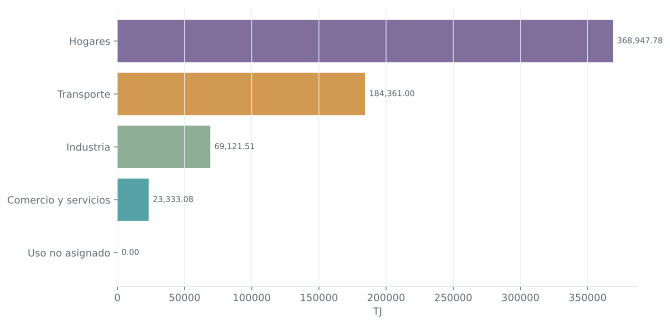

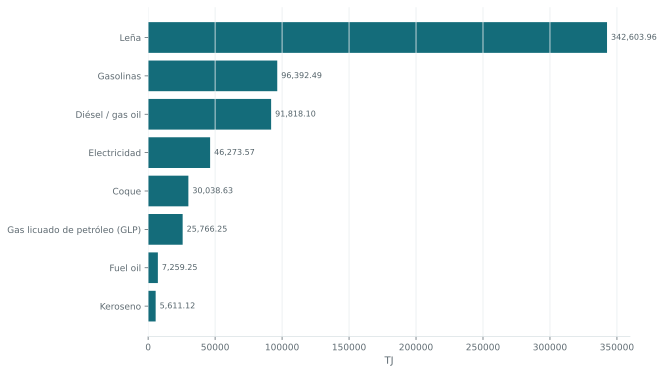

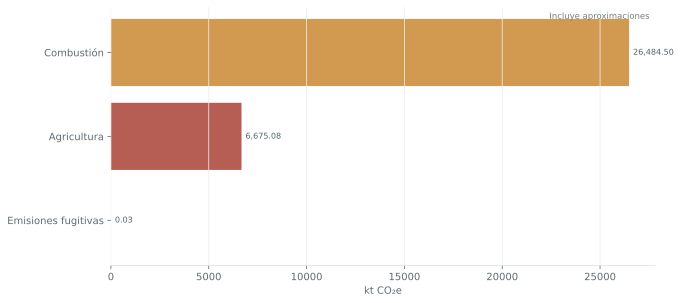

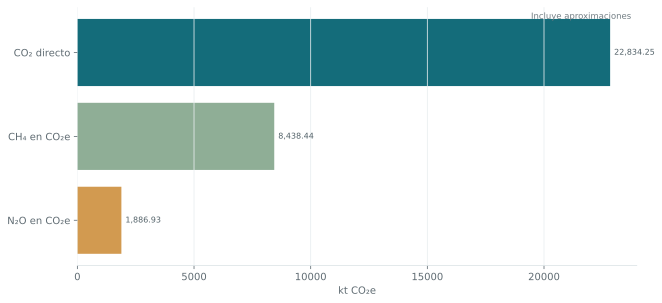

In [6]:
#@title { display-mode: "form" }
if HAY_WIDGETS:
    salida_uso_usuario = widgets.Output()
    salida_uso_producto = widgets.Output()
    salida_emisiones_modulo = widgets.Output()
    salida_emisiones_gas = widgets.Output()
    def _actualizar_graficos_anuales(cambio=None):
        anio = int(selector_anual.value)
        especificaciones = [
            (salida_uso_usuario, "Uso final por usuario", mostrar_uso_anual_unidad),
            (salida_uso_producto, "Uso final por producto", mostrar_uso_anual_producto),
            (salida_emisiones_modulo, "Emisiones cuantificadas por módulo", mostrar_emisiones_anual_modulo),
            (salida_emisiones_gas, "Contribución de los gases", mostrar_emisiones_anual_gas),
        ]
        for salida, titulo, funcion in especificaciones:
            with salida:
                _clear_output(wait=True)
                _display(_HTML(SUBCABECERA_GRAFICO.format(f"{titulo}, {anio}")))
                funcion(anio)
    selector_anual.observe(_actualizar_graficos_anuales, names="value")
    _actualizar_graficos_anuales()
    for salida in [salida_uso_usuario, salida_uso_producto, salida_emisiones_modulo, salida_emisiones_gas]:
        _display(salida)
else:
    for titulo, funcion in [
        ("Uso final por usuario", mostrar_uso_anual_unidad),
        ("Uso final por producto", mostrar_uso_anual_producto),
        ("Emisiones cuantificadas por módulo", mostrar_emisiones_anual_modulo),
        ("Contribución de los gases", mostrar_emisiones_anual_gas),
    ]:
        _display(_HTML(SUBCABECERA_GRAFICO.format(f"{titulo}, {ANIO_INICIAL}")))
        funcion(ANIO_INICIAL)


## 5. Evolución durante 2018–2024

Las siete figuras del período mantienen separadas las escalas de los componentes principales y de los ajustes menores. En las emisiones, 2023–2024 se identifica como un tramo que incluye aproximaciones.

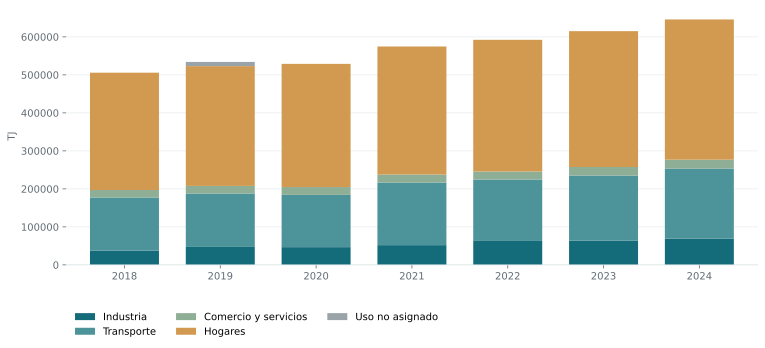

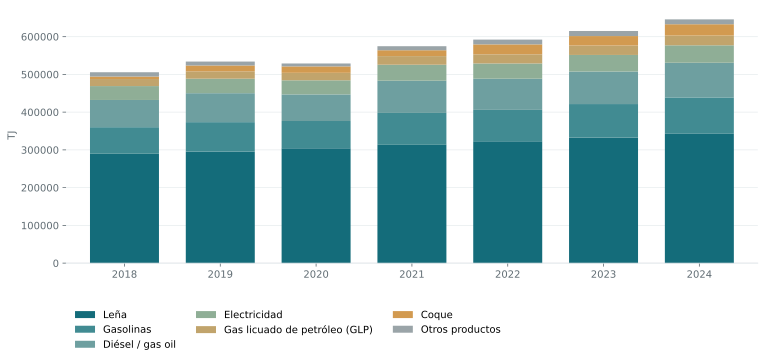

Año,Producción primariaTJ,ImportacionesTJ,ExportacionesTJ,Cambio de existenciasTJ,Oferta primaria aparenteTJ,Dependencia neta aparente%
2018,"396,762.81","251,007.75","32,860.95","-2,884.32","617,793.92",35.31
2019,"407,624.14","297,206.25","29,535.6","32,431.42","642,863.37",41.64
2020,"414,642.68","233,038.29","21,487.76","2,661.79","623,531.41",33.93
2021,"457,873.43","301,516.34","23,169.23","26,150.23","710,070.31",39.2
2022,"451,192.17","276,553.85","20,610.57","13,134.55","694,000.9",36.88
2023,"472,300.01","310,632.23","16,979.9","23,866.49","742,085.85",39.57
2024,"469,552.12","319,880.3","21,829.04","3,685.11","763,918.26",39.02


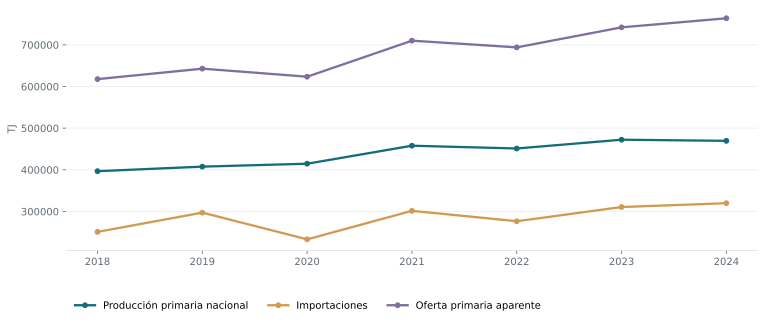

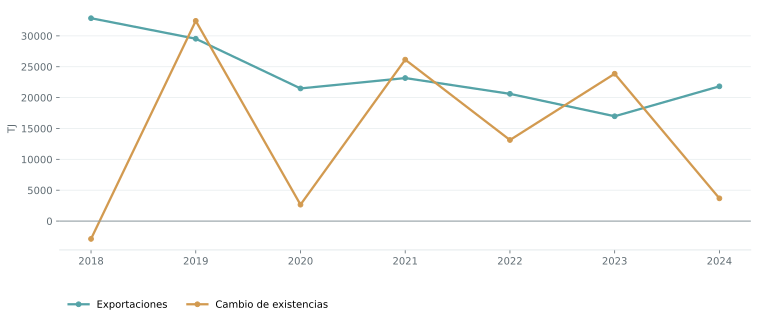

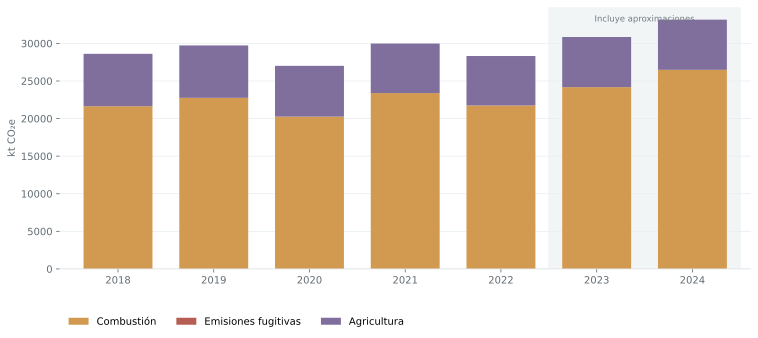

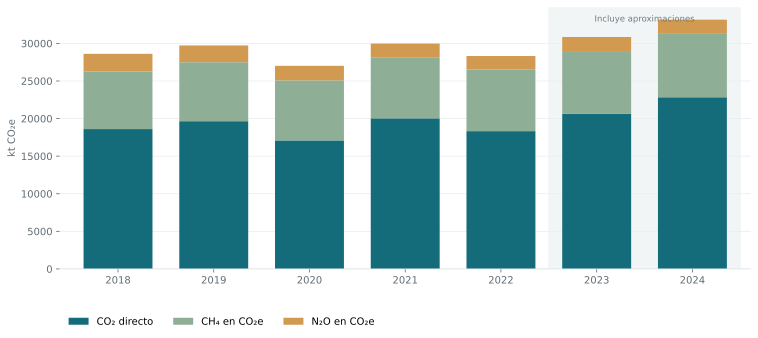

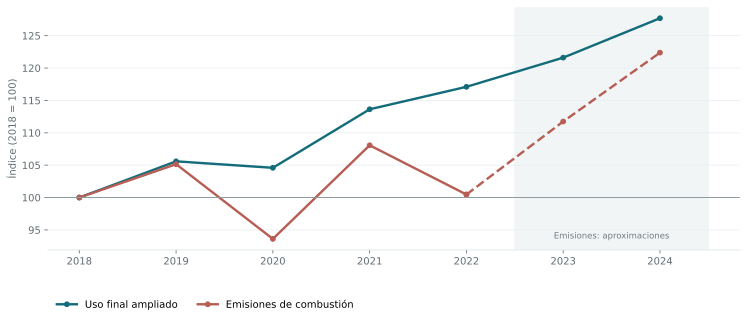

In [7]:
#@title { display-mode: "form" }
_display(_HTML(SUBCABECERA_GRAFICO.format("Uso final por usuario, 2018–2024")))
mostrar_uso_periodo_usuario()
_display(_HTML(SUBCABECERA_GRAFICO.format("Uso final por producto, 2018–2024")))
mostrar_uso_periodo_producto()
_display(_HTML(SUBCABECERA_GRAFICO.format("Oferta primaria aparente, 2018–2024")))
_display(_HTML(tabla_oferta_periodo_html()))
_display(_HTML(SUBCABECERA_GRAFICO.format("Componentes principales de la oferta primaria aparente")))
mostrar_oferta_componentes()
_display(_HTML(SUBCABECERA_GRAFICO.format("Exportaciones y cambio de existencias")))
mostrar_oferta_ajustes()
_display(_HTML(SUBCABECERA_GRAFICO.format("Emisiones cuantificadas por módulo, 2018–2024")))
mostrar_emisiones_periodo_modulo()
_display(_HTML(SUBCABECERA_GRAFICO.format("Contribución de los gases, 2018–2024")))
mostrar_emisiones_periodo_gas()
_display(_HTML(SUBCABECERA_GRAFICO.format("Energía y emisiones, índice 2018 = 100")))
mostrar_indice_energia_emisiones()


## Claves de lectura

- La PSUT organiza flujos físicos de energía; la cuenta de emisiones registra emisiones al aire asociadas con las actividades incluidas.
- Los residuales energéticos se presentan dentro de la PSUT, separados de los productos destinados al uso final.
- Una celda vacía indica que no existe un registro para esa combinación; no debe interpretarse como cero.
- El redondeo se aplica únicamente a la presentación.